In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker 
import matplotlib.colors as mcolors
from matplotlib import colormaps
from matplotlib.colors import Normalize
from scipy import fftpack
from scipy.sparse import csr_matrix
import scipy.sparse
# Importing fft functions from scipy
from scipy.fft import fft, fftfreq, fftshift

In [2]:
import random
import string
import time

def generate_password(length):
    """Generates a random password of a specified length."""
    # Define the pool of characters: letters (upper/lower), digits, and punctuation
    character_pool = string.ascii_letters + string.digits + string.punctuation
    # Generate the password using random choices from the pool (allowing repeats)
    password_list = [random.choice(character_pool) for _ in range(length)]
    # Join the list of characters into a string
    password = "".join(password_list)
    return password
# Generate a password with the original length of 30
password_length = 30
random_str = generate_password(password_length)
print(f"Password:", random_str)

Password: CTcZnT)@pXpy.fez(c4HU"@4h`V{ul


In [3]:
# matplotlib parameters 
large = 40; med = 30; small = 20
params = {'axes.titlesize': med,
          'axes.titlepad' : med,
          'legend.fontsize': med,
          'axes.labelsize': med ,
          'axes.titlesize': med ,
          'xtick.labelsize': med ,
          'ytick.labelsize': med ,
          'figure.titlesize': med}
plt.rcParams["font.family"] = "Helvetica"
plt.rcParams["font.serif"] = ["Helvetica Neue"]          
plt.rcParams['text.usetex'] = True # need LaTeX. Change it to False if LaTeX is not installed in the system
plt.rcParams.update(params)
PI = np.pi
H_BAR = 6.626*10**(-34)/(2*PI)

folder_name_dict = { 
                    # 'run_0': 0.0,
                    # 'run_0_29_30.5': 0.0,
                    'run_0.01':0.01,
                    'run_1': 0.1,
                    'run_2': 0.2,
                    'run_3': 0.3,
                    'run_4': 0.4,
                    'run_5': 0.5,
                    'run_6': 0.6,
                    'run_7': 0.7,
                    'run_8': 0.8,
                    'run_9': 0.9,
                    'run_10': 1.0}   

folder_name_lst = [keys for keys in folder_name_dict.keys()]
folder_name = folder_name_lst[1]
print("Folder name: ", folder_name)
total_number_of_b_folders = 128
b_index = total_number_of_b_folders - 1

# main_path = '/Volumes/SASANKA_SSD/atomtronics_backup/atomtronics_modular_data/zoomed_30_33/'
main_path = '/Volumes/SASANKA_SSD/atomtronics_backup/atomtronics_modular_data/'
# main_path = '/Volumes/SASANKA_SSD/atomtronics_backup/atomtronics_modular_data/zoomed_2/'
path = main_path + str(folder_name) + '/b' + str(b_index)
os.chdir(path)
number_of_atoms = 10 * 1.e3
print("Number of atoms: ", number_of_atoms)
a_s_factor = np.load("a_s_factor.npy") 
print("a_s = ", a_s_factor)
V_SG = 30 # kHz
V_GD = 33 # kHz
print("V_SG = ", V_SG, "kHz")
print("V_GD = ", V_GD, "kHz")

Folder name:  run_1
Number of atoms:  10000.0
a_s =  0.1
V_SG =  30 kHz
V_GD =  33 kHz


In [4]:
b_start = 0
b_end = total_number_of_b_folders - 1
b_index = b_start
path = main_path + str(folder_name) + '/b' + str(b_index)
os.chdir(path)
V_SS_start_factor = np.load("source_bias.npy")
print("V_SS_start_factor = ", V_SS_start_factor)
b_index = b_end
path = main_path + str(folder_name) + '/b' + str(b_index)
os.chdir(path)
V_SS_end_factor = np.load("source_bias.npy")
print("V_SS_end_factor = ", V_SS_end_factor)
V_SS_lst_to_plot = np.linspace(V_SS_start_factor, V_SS_end_factor, total_number_of_b_folders)

V_SS_start_factor =  21.0
V_SS_end_factor =  28.0


In [22]:
Rb87_a_s = 5.186 * 1.e-9
Rb87_a_s = Rb87_a_s * a_s_factor
print("Rb87_a_s = ", Rb87_a_s)

Rb87_a_s =  5.186e-10


In [23]:
PI = np.pi
H_BAR = 6.626*10**(-34)/(2*PI)
ATOM_MASS = 1.4192261*10**(-25) # kg
barrier_height_SG = V_SG # kHz
barrier_height_GD = V_GD # kHz
# mean_barrier_height = (barrier_height_SG + barrier_height_GD) / 2.0 # kHz
mean_barrier_height = barrier_height_SG
os.chdir(path)
gate_well_start = 0.0
gate_well_end = 4.8
print("Gate well width = ", gate_well_end - gate_well_start,r"$\mu m$")

single_particle_omega = np.sqrt(8*mean_barrier_height*10**3*H_BAR*2*PI/(ATOM_MASS*(gate_well_end*1.e-6 - gate_well_start*1.e-6)**2))
print(r"Single particle energy level frequency = ", single_particle_omega, "(rad/s)")
n_levels = int((barrier_height_SG*10**3*H_BAR*2*PI)/(H_BAR*7415) - 1/2)
print("Number of single particle energy levels in the gate well = ", n_levels)

single_particle_omega = 2*np.pi*1178
print("Time period = ", 2*np.pi/single_particle_omega * 1.e3, "s")

Gate well width =  4.8 $\mu m$
Single particle energy level frequency =  6973.716763152236 (rad/s)
Number of single particle energy levels in the gate well =  24
Time period =  0.8488964346349746 s


# Atom number as a function of time for every $V_{\mathrm{SS}}$ values

In [6]:
number_of_divisions = total_number_of_b_folders - b_start
chemical_potential_source_well_lst = []
source_atom_number_lst = []
gate_atom_number_lst = []
drain_atom_number_lst = []

# path = '/Volumes/SASANKA_SSD/atomtronics_backup/atomtronics_modular_data/zoomed_30_33/'
path = main_path + str(folder_name)
os.chdir(path)

for b in range(b_start, total_number_of_b_folders):
    print("b = ", b)
    path_b = path + "/b" + str(b) + "/"
    os.chdir(path_b)
    chemical_potential_source_well = np.load("chemical_potential_J.npy")
    source_atom_number = np.load("source_well_atom_numbers_vs_time_bias_idx_" + str(b) + ".npy")
    gate_atom_number = np.load("gate_well_atom_numbers_vs_time_bias_idx_" + str(b) + ".npy")
    drain_atom_number = np.load("drain_well_atom_numbers_vs_time_bias_idx_" + str(b) + ".npy")
    # chemical_potential_source_well_lst.append(chemical_potential_source_well[int(len(chemical_potential_source_well)/1.2)])
    chemical_potential_source_well_lst.append(chemical_potential_source_well)
    source_atom_number_lst.append(source_atom_number)
    gate_atom_number_lst.append(gate_atom_number)
    drain_atom_number_lst.append(drain_atom_number)

b =  0
b =  1
b =  2
b =  3
b =  4
b =  5
b =  6
b =  7
b =  8
b =  9
b =  10
b =  11
b =  12
b =  13
b =  14
b =  15
b =  16
b =  17
b =  18
b =  19
b =  20
b =  21
b =  22
b =  23
b =  24
b =  25
b =  26
b =  27
b =  28
b =  29
b =  30
b =  31
b =  32
b =  33
b =  34
b =  35
b =  36
b =  37
b =  38
b =  39
b =  40
b =  41
b =  42
b =  43
b =  44
b =  45
b =  46
b =  47
b =  48
b =  49
b =  50
b =  51
b =  52
b =  53
b =  54
b =  55
b =  56
b =  57
b =  58
b =  59
b =  60
b =  61
b =  62
b =  63
b =  64
b =  65
b =  66
b =  67
b =  68
b =  69
b =  70
b =  71
b =  72
b =  73
b =  74
b =  75
b =  76
b =  77
b =  78
b =  79
b =  80
b =  81
b =  82
b =  83
b =  84
b =  85
b =  86
b =  87
b =  88
b =  89
b =  90
b =  91
b =  92
b =  93
b =  94
b =  95
b =  96
b =  97
b =  98
b =  99
b =  100
b =  101
b =  102
b =  103
b =  104
b =  105
b =  106
b =  107
b =  108
b =  109
b =  110
b =  111
b =  112
b =  113
b =  114
b =  115
b =  116
b =  117
b =  118
b =  119
b =  120
b =  121
b =  122
b =

In [7]:
# fig, ax = plt.subplots(figsize=(10, 7))

# tinit = 0.0 * 1.e-3
# tmax = 300 * 1.e-3  # In seconds unit.
# dt = 10**(-6)
# time_lst = np.arange(0.0 * 1.e-3, tmax, dt)[:-1]  # Exclude last point to match array lengths
# time_in_ms = time_lst * 1000  # Convert to milliseconds

# # First b_index
# b_index1 = 8
# # Plot data for first b_index with solid lines
# ax.plot(time_in_ms, gate_atom_number_lst[b_index1][:len(time_lst)]/1.e2, color='blue', 
#      linewidth=2.5, label=r'Gate ($V_{\mathrm{SS}}$ = '+str(round(V_SS_lst_to_plot[b_index1], 2))+' kHz)', 
#      linestyle='-')
# ax.plot(time_in_ms, drain_atom_number_lst[b_index1][:len(time_lst)]/1.e2, color='orangered', 
#      linewidth=2.5, label=r'Drain ($V_{\mathrm{SS}}$ = '+str(round(V_SS_lst_to_plot[b_index1], 2))+' kHz)', 
#      linestyle='-')

# # Second b_index
# b_index2 = 60
# # Plot data for second b_index with dashed lines
# ax.plot(time_in_ms, gate_atom_number_lst[b_index2][:len(time_lst)]/1.e2, color='forestgreen', 
#      linewidth=2.5, label=r'Gate ($V_{\mathrm{SS}}$ = '+str(round(V_SS_lst_to_plot[b_index2], 2))+' kHz)', 
#      linestyle='--')
# ax.plot(time_in_ms, drain_atom_number_lst[b_index2][:len(time_lst)]/1.e2, color='k', 
#      linewidth=2.5, label=r'Drain ($V_{\mathrm{SS}}$ = '+str(round(V_SS_lst_to_plot[b_index2], 2))+' kHz)', 
#      linestyle='--')

# # Setting labels
# ax.set_xlabel(r'Time (ms)', labelpad=15)
# ax.set_ylabel(r'Atom numbers ($\times 10^{2}$)', labelpad=15)

# # Customizing tick parameters
# ax.tick_params(axis='x', direction='out', length=10, width=2, color='k')
# ax.tick_params(axis='y', direction='out', length=10, width=2, color='k')

# # Customizing spines
# for spine in ax.spines.values():
#     spine.set_linewidth(2)
    
# ax.legend(fontsize=med)
# # path = '/Users/sasankadowarah/atomtronics/after_APS_figures/resolution_15_time_6/peak_FFT_heights/'
# # os.chdir(path)
# # plt.savefig('atom_numbers_gate_drain_b_index_'+str(b_index1)+'_'+str(b_index2)+'.pdf', dpi=600, bbox_inches='tight')
# plt.show()

# Final atom numbers as a function of $V_{SS}$

In [8]:
dt = 1.e-6
time_lst = np.arange(0, 300*1.e-3, dt)

tfinal = 300*1.e-3
index_closest = np.argmin(np.abs(time_lst - tfinal))

source_well_final_atom_number_lst = []
gate_well_final_atom_number_lst = []
drain_well_final_atom_number_lst = []    
for i in range(total_number_of_b_folders - b_start):
     print("b = ", i)
     source_well_final_atom_number_lst.append(source_atom_number_lst[i][:,1][-1])
     gate_well_final_atom_number_lst.append(gate_atom_number_lst[i][:,1][-1])
     drain_well_final_atom_number_lst.append(drain_atom_number_lst[i][:,1][-1])

b =  0
b =  1
b =  2
b =  3
b =  4
b =  5
b =  6
b =  7
b =  8
b =  9
b =  10
b =  11
b =  12
b =  13
b =  14
b =  15
b =  16
b =  17
b =  18
b =  19
b =  20
b =  21
b =  22
b =  23
b =  24
b =  25
b =  26
b =  27
b =  28
b =  29
b =  30
b =  31
b =  32
b =  33
b =  34
b =  35
b =  36
b =  37
b =  38
b =  39
b =  40
b =  41
b =  42
b =  43
b =  44
b =  45
b =  46
b =  47
b =  48
b =  49
b =  50
b =  51
b =  52
b =  53
b =  54
b =  55
b =  56
b =  57
b =  58
b =  59
b =  60
b =  61
b =  62
b =  63
b =  64
b =  65
b =  66
b =  67
b =  68
b =  69
b =  70
b =  71
b =  72
b =  73
b =  74
b =  75
b =  76
b =  77
b =  78
b =  79
b =  80
b =  81
b =  82
b =  83
b =  84
b =  85
b =  86
b =  87
b =  88
b =  89
b =  90
b =  91
b =  92
b =  93
b =  94
b =  95
b =  96
b =  97
b =  98
b =  99
b =  100
b =  101
b =  102
b =  103
b =  104
b =  105
b =  106
b =  107
b =  108
b =  109
b =  110
b =  111
b =  112
b =  113
b =  114
b =  115
b =  116
b =  117
b =  118
b =  119
b =  120
b =  121
b =  122
b =

# Drain and gate atom numbers as a function of $V_{SS}$

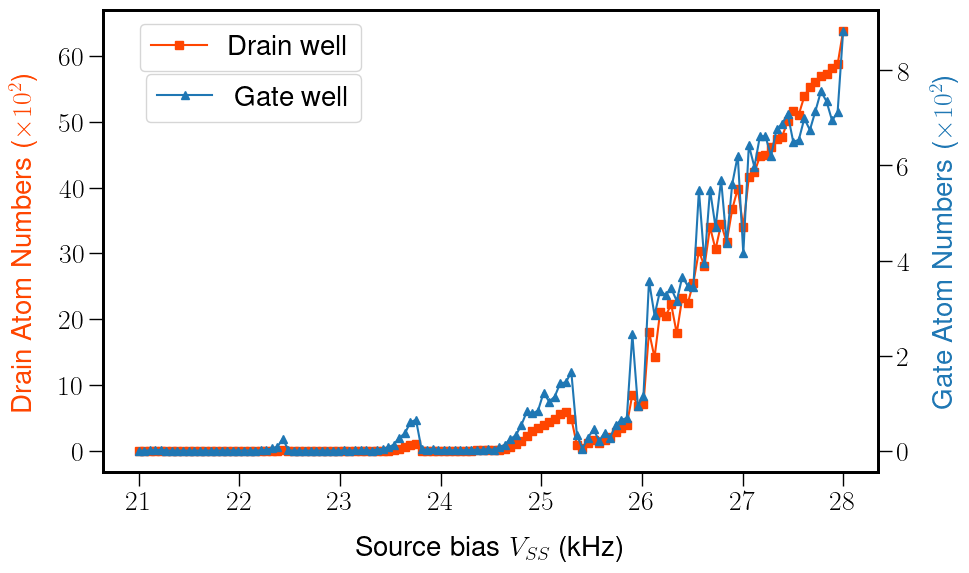

In [9]:
# matplotlib parameters 
large = 40; med = 20; small = 20
params = {'axes.titlesize': med,
          'axes.titlepad' : med,
          'legend.fontsize': med,
          'axes.labelsize': med ,
          'axes.titlesize': med ,
          'xtick.labelsize': med ,
          'ytick.labelsize': med ,
          'figure.titlesize': med}
plt.rcParams["font.family"] = "Helvetica"
plt.rcParams["font.serif"] = ["Helvetica Neue"]          
#plt.rcParams['text.usetex'] = True # need LaTeX. Change it to False if LaTeX is not installed in the system
plt.rcParams.update(params)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax3 = ax1.twinx()  # Create a second y-axis

gate_color = "tab:blue"
drain_color = "orangered"

#source_bias_to_plot = np.array(chemical_potential_source_well_lst)/(10**3*2*PI*H_BAR)
# Plotting the data
V_SS_lst_to_plot = np.linspace(V_SS_start_factor, V_SS_end_factor, total_number_of_b_folders)
ax1.plot(V_SS_lst_to_plot, np.array(drain_well_final_atom_number_lst) / 100, color=drain_color, marker="s", label="Drain well", markersize=6, linewidth=1.5)
ax3.plot(V_SS_lst_to_plot, np.array(gate_well_final_atom_number_lst) / 100, color=gate_color, marker="^", label="Gate well", markersize=6, linewidth=1.5)

# Setting labels
ax1.set_xlabel(r" Source bias $V_{SS}$ (kHz)", labelpad=15)
ax1.set_ylabel("Drain Atom Numbers ($\\times 10^{2}$)", labelpad=15, color=drain_color)
ax3.set_ylabel("Gate Atom Numbers ($\\times 10^{2}$)", labelpad=15, color=gate_color)

# Setting axis limits
#ax1.set_xlim([a_s_lst_to_plot[0], a_s_lst_to_plot[-1] + 0.2])

# Customizing tick parameters
ax1.tick_params(axis="x", direction="out", length=10, width=1, color="k")
ax1.tick_params(axis="y", direction="out", length=10, width=1, color="k")
ax3.tick_params(axis="y", direction="out", length=10, width=1, color="k")

# Customizing spines
for spine in ax1.spines.values():
    spine.set_linewidth(2)
for spine in ax3.spines.values():
    spine.set_linewidth(2)

ax1.legend(loc="upper right", bbox_to_anchor=(0.35, 1))
ax3.legend(loc="upper right", bbox_to_anchor=(0.35, 0.89))
#ax1.set_xlim(22.8, 30.2)
#ax1.set_xlim(24, 32)
#ax1.axvline(x=V_SS_lst_to_plot[45], color='k', linestyle='--', linewidth=1)
# path = "/Users/sasankadowarah/atomtronics/triple-well-transistor/"+str(folder_name)+"/"
# os.chdir(path)
# path = '/Users/sasankadowarah/atomtronics/after_APS_figures/resolution_15_time_6/128/'
# os.chdir(path)
# plt.savefig("final_atom_numbers_vs_V_SS_"+str(tfinal)+"_"+str(folder_name)+".png", dpi=600, bbox_inches="tight")
plt.show()

# Drain and gate atom numbers as a function of chemical potential $\mu$

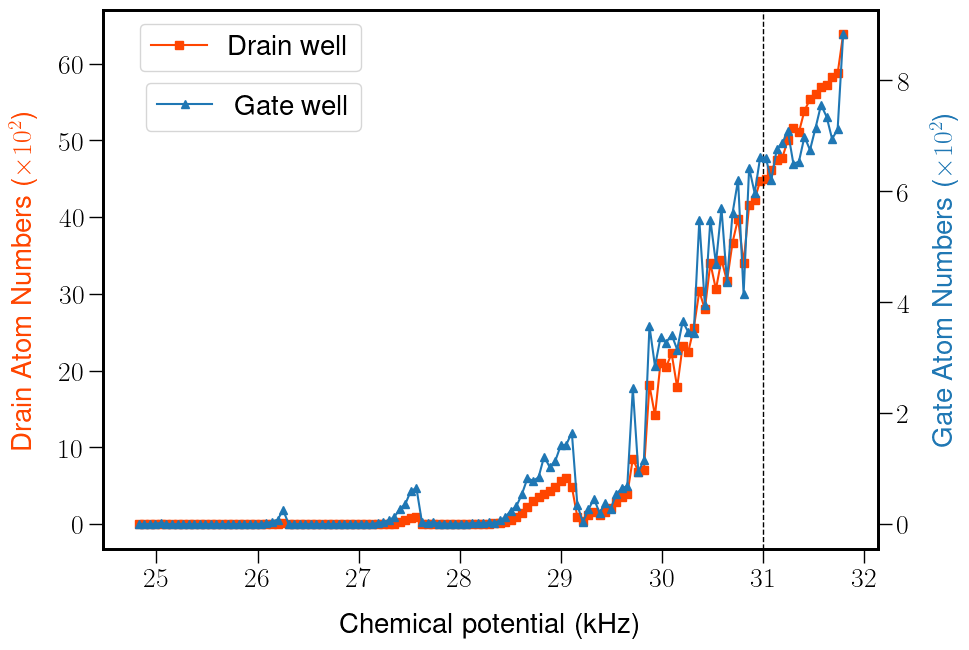

In [10]:
fig, ax1 = plt.subplots(figsize=(10, 7))
ax3 = ax1.twinx()  # Create a second y-axis

gate_color = "tab:blue"
drain_color = "orangered"

mu_lst_to_plot = np.array(chemical_potential_source_well_lst)/(10**3*2*PI*H_BAR)
# Plotting the data
ax1.plot(mu_lst_to_plot , np.array(drain_well_final_atom_number_lst) / 100, color=drain_color, marker="s", label="Drain well", markersize=6, linewidth=1.5)
ax3.plot(mu_lst_to_plot , np.array(gate_well_final_atom_number_lst) / 100, color=gate_color, marker="^", label="Gate well", markersize=6, linewidth=1.5)

# Setting labels
ax1.set_xlabel("Chemical potential (kHz)", labelpad=15)
ax1.set_ylabel("Drain Atom Numbers ($\\times 10^{2}$)", labelpad=15, color=drain_color)
ax3.set_ylabel("Gate Atom Numbers ($\\times 10^{2}$)", labelpad=15, color=gate_color)

# Setting axis limits
#ax1.set_xlim([mu_lst_to_plot[0], 31])

# Customizing tick parameters
ax1.tick_params(axis="x", direction="out", length=10, width=1, color="k")
ax1.tick_params(axis="y", direction="out", length=10, width=1, color="k")
ax3.tick_params(axis="y", direction="out", length=10, width=1, color="k")

# Customizing spines
for spine in ax1.spines.values():
    spine.set_linewidth(2)
for spine in ax3.spines.values():
    spine.set_linewidth(2)

ax1.legend(loc="upper right", bbox_to_anchor=(0.35, 1))
ax3.legend(loc="upper right", bbox_to_anchor=(0.35, 0.89))
#ax1.set_xlim(22.8, 30.2)
#ax1.set_xlim(24, 32)
ax1.axvline(x=31, color='k', linestyle='--', linewidth=1)
#ax1.axvline(x = mu_lst_to_plot[45], color='r', linestyle='--', linewidth=1)
# path = '/Users/sasankadowarah/atomtronics/after_APS_figures/resolution_15_time_6/128/'
# os.chdir(path)
# plt.savefig("final_atom_numbers_vs_chemical_potential_"+str(tfinal)+".png", dpi=600, bbox_inches="tight")
plt.show()

In [11]:
# Find the index where mu_lst_to_plot is closest to 31 kHz
mu_target = 31  # kHz
index_closest_mu = np.argmin(np.abs(mu_lst_to_plot - mu_target))

# Find the corresponding V_SS value
V_SS_at_mu_31 = V_SS_lst_to_plot[index_closest_mu]

print(f"The V_SS value where mu is closest to 31 kHz is: {V_SS_at_mu_31:.3f} kHz")

The V_SS value where mu is closest to 31 kHz is: 27.173 kHz


# FFT peak near $\omega=\omega_{\mathrm{Gate}}$ as a function of $V_{SS}$

In [12]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit  # <-- import curve fitting

# Define a Gaussian function
def gaussian(x, a, x0, sigma):
    return a * np.exp(-(x - x0) ** 2 / (2 * sigma ** 2))

# Initialize the list to store peak heights
peak_heights_drain = []
peak_heights_gate = []
peak_heights_source = []
b_index_lst = [i for i in range(b_start, total_number_of_b_folders)]
tinit = 0.0 * 1.e-3
tmax = 300 * 1.e-3  # In seconds unit.
dt = 10**(-6)
time_lst = np.arange(0.0 * 1.e-3, tmax, dt)[:-1]

omega_window = [(single_particle_omega - single_particle_omega/15)/(2*np.pi), (single_particle_omega + single_particle_omega/15)/(2*np.pi)]

for b_index in b_index_lst:
    path = main_path+ str(folder_name)+ '/b' + str(b_index)
    os.chdir(path)
    number_of_atoms = 1.e4
    V_SG = 30
    V_GD = 33

    wavefunction_at_fixed_point_drain_arr = np.load("wavefunction_at_40um_vs_time_bias_idx_" + str(b_index) + ".npy")[:,1]
    density_drain = np.abs(wavefunction_at_fixed_point_drain_arr) ** 2

    index_closest = np.argmin(np.abs(time_lst - tinit))
    density_drain = density_drain[index_closest:len(time_lst)]

    # Peak heights in the drain
    signal = density_drain
    signal = signal - np.mean(signal)

    # Apply Savgol filter
    window_length = 51  # Must be odd
    polyorder = 2
    signal_smoothed = savgol_filter(signal, window_length=window_length, polyorder=polyorder)

    n = len(signal_smoothed)
    fft_result = np.fft.fft(signal_smoothed)
    frequencies = np.fft.fftfreq(n, d=dt)
    fft_result_shifted = fft_result
    frequencies_shifted = frequencies
    power_spectrum = np.abs(fft_result_shifted) ** 2

    # Only consider positive frequencies
    positive_freq_indices = frequencies_shifted > 0
    positive_frequencies = frequencies_shifted[positive_freq_indices]
    positive_power_spectrum = power_spectrum[positive_freq_indices]

    # Select the window in frequency
    lower_bound, upper_bound = omega_window
    window_indices = np.where((positive_frequencies >= lower_bound) & (positive_frequencies <= upper_bound))[0]

    print("Lower bound: ", lower_bound, "Upper bound: ", upper_bound)
    print("Number of points in window: ", len(window_indices))

    if len(window_indices) > 5:  # make sure there are enough points to fit
        freqs_to_fit = positive_frequencies[window_indices]
        powers_to_fit = positive_power_spectrum[window_indices]

        # Initial guess: [amplitude, center frequency, width]
        guess_amplitude = np.max(powers_to_fit)
        guess_center = freqs_to_fit[np.argmax(powers_to_fit)]
        guess_sigma = (upper_bound - lower_bound) / 10  # rough guess

        try:
            popt, pcov = curve_fit(gaussian, freqs_to_fit, powers_to_fit, 
                                   p0=[guess_amplitude, guess_center, guess_sigma])
            fitted_amplitude, fitted_center, fitted_sigma = popt
            peak_height_drain = fitted_amplitude
        except RuntimeError:
            print("Gaussian fit failed for b_index = ", b_index)
            peak_height_drain = 0
    else:
        print("Not enough points in range for fitting.")
        peak_height_drain = 0

    peak_heights_drain.append(peak_height_drain)

Lower bound:  1099.4666666666667 Upper bound:  1256.5333333333333
Number of points in window:  47
Gaussian fit failed for b_index =  0
Lower bound:  1099.4666666666667 Upper bound:  1256.5333333333333
Number of points in window:  47
Gaussian fit failed for b_index =  1
Lower bound:  1099.4666666666667 Upper bound:  1256.5333333333333
Number of points in window:  47
Gaussian fit failed for b_index =  2
Lower bound:  1099.4666666666667 Upper bound:  1256.5333333333333
Number of points in window:  47
Lower bound:  1099.4666666666667 Upper bound:  1256.5333333333333
Number of points in window:  47
Lower bound:  1099.4666666666667 Upper bound:  1256.5333333333333
Number of points in window:  47
Gaussian fit failed for b_index =  5
Lower bound:  1099.4666666666667 Upper bound:  1256.5333333333333
Number of points in window:  47
Gaussian fit failed for b_index =  6
Lower bound:  1099.4666666666667 Upper bound:  1256.5333333333333
Number of points in window:  47
Gaussian fit failed for b_index

# Drain atom number and maximum FFT peak as a function of $V_{SS}$

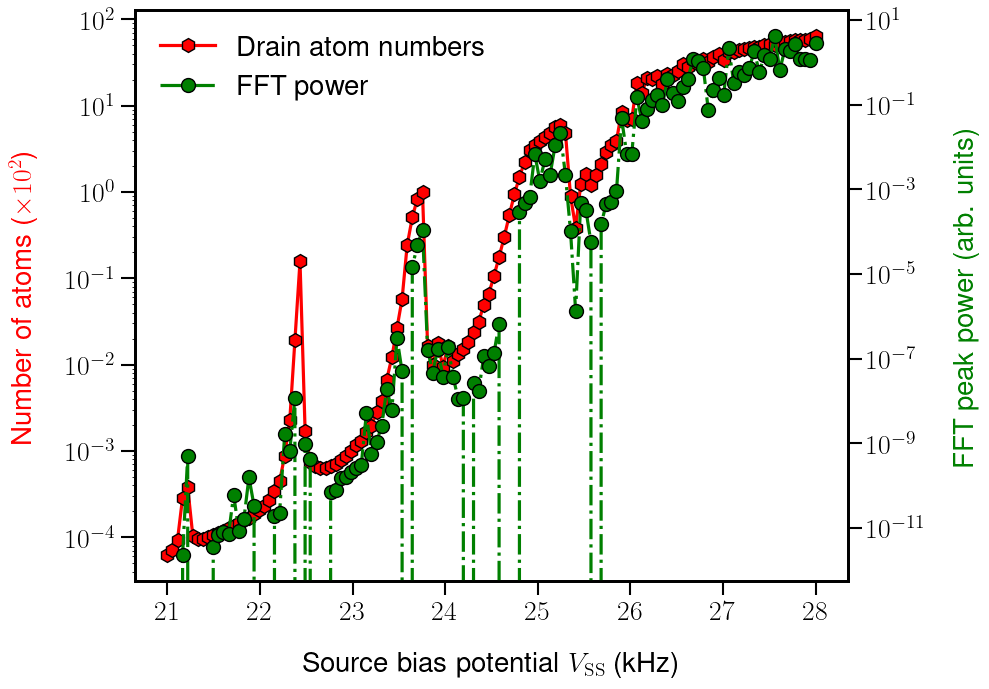

In [13]:
# Set matplotlib parameters for professional-looking plots
large = 40; med = 20; small = 20
params = {
        'axes.titlesize': med,
        'axes.titlepad': med,
        'legend.fontsize': med,
        'axes.labelsize': med,
        'xtick.labelsize': med,
        'ytick.labelsize': med,
        'figure.titlesize': med
}
plt.rcParams["font.family"] = "Helvetica"
plt.rcParams["font.serif"] = ["Helvetica Neue"]
plt.rcParams.update(params)

# Create figure and axes
fig, ax1 = plt.subplots(figsize=(10, 7))

# Set colors for different data series
color_drain = "red"
color_peak = "green"

# Create secondary y-axis
ax2 = ax1.twinx()

# Plot drain atom numbers on primary y-axis
ax1.plot(V_SS_lst_to_plot, 
                 np.array(drain_well_final_atom_number_lst) / 100,
                 color=color_drain, 
                 marker='h',
                 markersize=10,
                 markeredgecolor='black',
                 linewidth=2.3,
                 label='Drain atom numbers')

ax2.plot(V_SS_lst_to_plot, np.array(peak_heights_drain), 
                                 color=color_peak,
                                 marker='o',
                                 markeredgecolor='black',
                                 markersize=10,
                                 linewidth=2.3, 
                                 linestyle='-.',
                                 label='FFT power')


# ax1.axvline(x = 30.3, color='k', linestyle='--', linewidth = 1, label = r'$\mu = 31$ kHz')
# Set labels with proper font sizes
ax1.set_xlabel(r"Source bias potential $V_{\mathrm{SS}}$ (kHz)", labelpad = 20)
ax1.set_ylabel(r'Number of atoms ($\times 10^{2}$)', color=color_drain, labelpad = 20)
ax2.set_ylabel(r"FFT peak power (arb. units)", color=color_peak, labelpad = 20)

# # Set scales to logarithmic
ax1.set_yscale('log')
ax2.set_yscale('log')

# Customize tick parameters
for ax in [ax1, ax2]:
        ax.tick_params(axis='both', direction='out', length=10, width=1.5)

# Set spine properties
for spine in ax1.spines.values():
        spine.set_linewidth(2)
for spine in ax2.spines.values():
        spine.set_linewidth(2)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', ncol=1, frameon=False)
# Adjust layout
plt.tight_layout()
# path = '/Users/sasankadowarah/atomtronics/after_APS_figures/resolution_15_time_6/peak_FFT_heights/'
# os.chdir(path)
# plt.savefig('peak_FFT_heights_vs_V_SS_'+str(folder_name)+'.pdf', dpi=600, bbox_inches='tight')
plt.show()

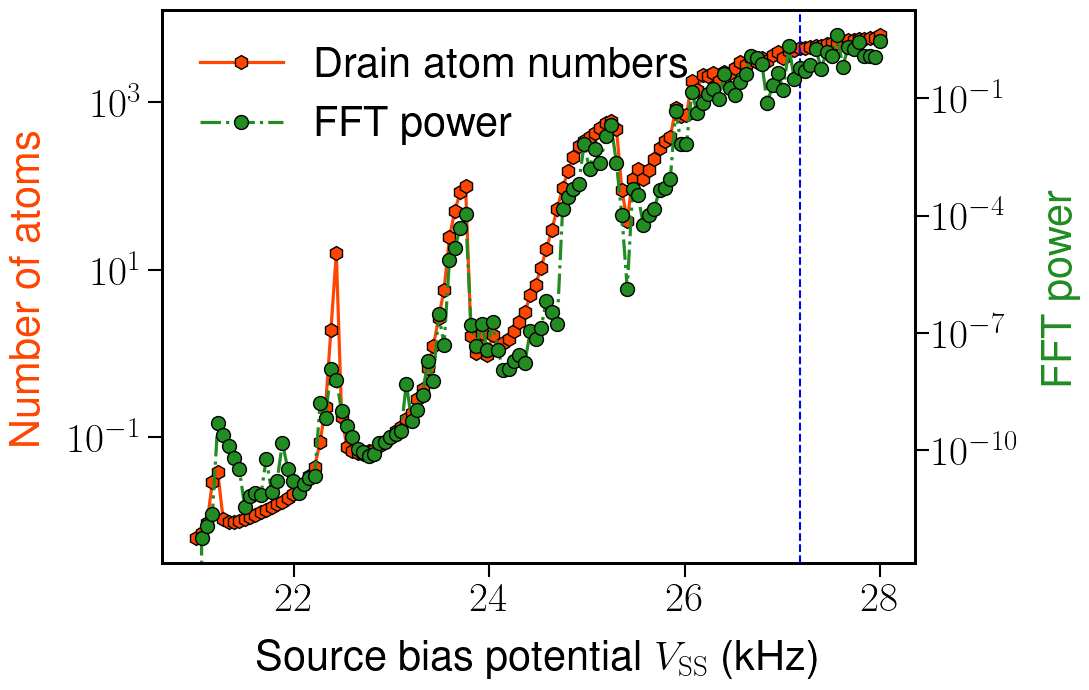

In [19]:
# matplotlib parameters 
large = 40; med = 30; small = 20
params = {'axes.titlesize': med,
          'axes.titlepad' : med,
          'legend.fontsize': med,
          'axes.labelsize': med ,
          'axes.titlesize': med ,
          'xtick.labelsize': med ,
          'ytick.labelsize': med ,
          'figure.titlesize': med}
plt.rcParams["font.family"] = "Helvetica"
plt.rcParams["font.serif"] = ["Helvetica Neue"]          
plt.rcParams['text.usetex'] = True # need LaTeX. Change it to False if LaTeX is not installed in the system
plt.rcParams.update(params)

# Create figure and axes
fig, ax1 = plt.subplots(figsize=(11, 7))

# Set colors for different data series
color_drain = "orangered"
color_peak = "forestgreen"

# Create secondary y-axis
ax2 = ax1.twinx()

# Replace zero data in peak_heights_drain with the average of the neighboring values
for i in range(1, len(peak_heights_drain) - 1):
     if peak_heights_drain[i] == 0:
          peak_heights_drain[i] = (peak_heights_drain[i - 1] + peak_heights_drain[i + 1]) / 2

# Plot drain atom numbers on primary y-axis
ax1.plot(V_SS_lst_to_plot, 
           np.array(drain_well_final_atom_number_lst),
           color=color_drain, 
           marker='h',
           markersize=10,
           markeredgecolor='black',
           linewidth=2.3,
           label='Drain atom numbers',
           )

ax2.plot(V_SS_lst_to_plot, np.array(peak_heights_drain), 
           color=color_peak,
           marker='o',
           markeredgecolor='black',
           markersize=10,
           linewidth=2.3, 
           linestyle='-.',
           label='FFT power')

# Vertical line at V_SS_at_mu_31
ax1.axvline(x = V_SS_at_mu_31, color='blue', linestyle='--', linewidth = 1.5)

# ax1.axvline(x = 30.3, color='k', linestyle='--', linewidth = 1, label = r'$\mu = 31$ kHz')
# Set labels with proper font sizes
ax1.set_xlabel(r"Source bias potential $V_{\mathrm{SS}}$ (kHz)", labelpad = 15)
ax1.set_ylabel(r'Number of atoms', color=color_drain, labelpad = 15)
ax2.set_ylabel(r"FFT power", color=color_peak, labelpad = 15)

# Set the y axis limit for the drain atom numbers starting from 1
# ax1.set_ylim(1, 1.5 * np.max(np.array(drain_well_final_atom_number_lst)))
# # Set scales to logarithmic
ax1.set_yscale('log')
ax2.set_yscale('log')

# Customize tick parameters
for ax in [ax1, ax2]:
        ax.tick_params(axis='both', direction='out', length=10, width=1.5)

# Set spine properties
for spine in ax1.spines.values():
        spine.set_linewidth(2)
for spine in ax2.spines.values():
        spine.set_linewidth(2)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', ncol=1, frameon=False)
# Adjust layout
plt.tight_layout()
path = '/Volumes/SASANKA_SSD/atomtronics_backup/atomtronics_modular_data/'
os.chdir(path)
plt.savefig('peak_FFT_heights_vs_V_SS_'+str(folder_name)+'.pdf', dpi=600, bbox_inches='tight')
plt.show()

# Drain atom numbers and maximum FFT peak heights as a function of chemical potential

In [15]:
# # matplotlib parameters 
# large = 40; med = 20; small = 20
# params = {'axes.titlesize': med,
#             'axes.titlepad' : med,
#             'legend.fontsize': med,
#             'axes.labelsize': med,
#             'axes.titlesize': med,
#             'xtick.labelsize': med,
#             'ytick.labelsize': med,
#             'figure.titlesize': med}
# plt.rcParams["font.family"] = "Helvetica"
# plt.rcParams["font.serif"] = ["Helvetica Neue"]
# #plt.rcParams['text.usetex'] = True # need LaTeX. Change it to False if LaTeX is not installed in the system
# plt.rcParams.update(params)

# fig, ax1 = plt.subplots(figsize=(10, 6))

# # Plotting drain atom numbers on the primary y-axis
# color_drain = "orangered"
# ax1.set_xlabel(r"Chemical potential $\mu$ (kHz)", fontsize=med, labelpad=15)
# ax1.set_ylabel('Drain atom numbers ($\\times 10^{2}$)', fontsize=med, color=color_drain, labelpad=15)

# ax1.plot(mu_lst_to_plot, np.array(drain_well_final_atom_number_lst) / 100, color=color_drain, marker='X', label='Drain atom numbers', markersize=8, linewidth=2)
# ax1.tick_params(axis='y', labelcolor=color_drain, labelsize=med)

# # Creating a secondary y-axis for the peak heights
# ax2 = ax1.twinx()
# color_peak = "forestgreen"
# ax2.set_ylabel(r"FFT peak power", fontsize=med, color=color_peak, labelpad=15)
# ax2.plot(mu_lst_to_plot, np.array(peak_heights_drain), color=color_peak, marker='o', markersize=8, linewidth=2, label="FFT peak power")
# ax2.tick_params(axis='y', labelcolor=color_peak, labelsize=med)

# # Customizing tick parameters
# ax1.tick_params(axis='x', direction='out', length=10, width=2, color='k', labelsize=med)
# ax1.tick_params(axis='y', direction='out', length=10, width=2, color='k', labelsize=med)
# ax2.tick_params(axis='y', direction='out', length=10, width=2, color='k', labelsize=med)

# # Adding minor ticks
# ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
# ax1.tick_params(which='minor', length=5, width=1, direction='out')

# # Customizing spines
# for spine in ax1.spines.values():
#       spine.set_linewidth(2)
# for spine in ax2.spines.values():
#       spine.set_linewidth(2)

# # Adding legends
# ax1.legend(loc="upper right", bbox_to_anchor=(0.51, 1), fontsize=med)
# ax2.legend(loc="upper right", bbox_to_anchor=(0.45, 0.87), fontsize=med)

# # Custom y-ticks for drain atom numbers
# drain_ticks = ax1.get_yticks()
# ax1.set_yticklabels([f'{float(np.around(tick,4))}' for tick in drain_ticks], fontsize=med)
# plt.axvline(x=31, color='k', linestyle='--', linewidth=1)

# # path = "/Users/sasankadowarah/atomtronics/triple-well-transistor/"+str(folder_name)+"/"
# os.chdir(path)
# # path = '/Users/sasankadowarah/atomtronics/after_APS_figures/resolution_15_time_6/128/'
# # os.chdir(path)
# # plt.savefig("drain_atom_numbers_peak_power_vs_mu_"+str(tmax*1.e3)+"ms_"+str(folder_name)+".png", dpi=600, bbox_inches="tight")
# plt.show()